<a href="https://colab.research.google.com/github/asternoeld/practical-ml-25-26/blob/main/assignment4/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision

In [2]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch import nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

In [3]:
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [4]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128
)

In [6]:
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


In [7]:
model.fc = nn.Linear(
    in_features=512,
    out_features=10
)

In [8]:
for param in model.parameters():
    param.requires_grad = True

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [10]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cpu
False


In [11]:
import torch
print(torch.cuda.is_available())

False


In [12]:
import sys
print(sys.executable)

/usr/bin/python3


In [13]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

Torch: 2.11.0+cpu
CUDA available: False
CUDA device count: 0


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

epochs = 10

for epoch in range(epochs):

    model.train()

    progress_bar = tqdm(train_loader)

    for batch_idx, (X, y) in enumerate(progress_bar):

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        progress_bar.set_description(
           f"Epoch {epoch+1} Loss {loss.item():.4f}"
           )

        if batch_idx % 20 == 0:
            print(
                f"Epoch {epoch+1} "
                f"Batch {batch_idx}/{len(train_loader)} "
                f"Loss={loss.item():.4f}"
            )

    print(f"Finished Epoch {epoch+1}")

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 Batch 0/469 Loss=2.5317
Epoch 1 Batch 20/469 Loss=0.6592
Epoch 1 Batch 40/469 Loss=0.2579
Epoch 1 Batch 60/469 Loss=0.1876
Epoch 1 Batch 80/469 Loss=0.1115
Epoch 1 Batch 100/469 Loss=0.0751
Epoch 1 Batch 120/469 Loss=0.1378
Epoch 1 Batch 140/469 Loss=0.1113
Epoch 1 Batch 160/469 Loss=0.1031
Epoch 1 Batch 180/469 Loss=0.0873
Epoch 1 Batch 200/469 Loss=0.0612
Epoch 1 Batch 220/469 Loss=0.0622
Epoch 1 Batch 240/469 Loss=0.0377
Epoch 1 Batch 260/469 Loss=0.0110
Epoch 1 Batch 280/469 Loss=0.0785
Epoch 1 Batch 300/469 Loss=0.0928
Epoch 1 Batch 320/469 Loss=0.0245
Epoch 1 Batch 340/469 Loss=0.0301
Epoch 1 Batch 360/469 Loss=0.0526
Epoch 1 Batch 380/469 Loss=0.0810
Epoch 1 Batch 400/469 Loss=0.1651
Epoch 1 Batch 420/469 Loss=0.0459
Epoch 1 Batch 440/469 Loss=0.1002
Epoch 1 Batch 460/469 Loss=0.0317
Finished Epoch 1


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 Batch 0/469 Loss=0.0433
Epoch 2 Batch 20/469 Loss=0.0055
Epoch 2 Batch 40/469 Loss=0.0206
Epoch 2 Batch 60/469 Loss=0.0323
Epoch 2 Batch 80/469 Loss=0.0515
Epoch 2 Batch 100/469 Loss=0.0422
Epoch 2 Batch 120/469 Loss=0.0466
Epoch 2 Batch 140/469 Loss=0.0028
Epoch 2 Batch 160/469 Loss=0.0242
Epoch 2 Batch 180/469 Loss=0.0022
Epoch 2 Batch 200/469 Loss=0.0108
Epoch 2 Batch 220/469 Loss=0.0437
Epoch 2 Batch 240/469 Loss=0.0665
Epoch 2 Batch 260/469 Loss=0.0177
Epoch 2 Batch 280/469 Loss=0.0103
Epoch 2 Batch 300/469 Loss=0.0558
Epoch 2 Batch 320/469 Loss=0.0226
Epoch 2 Batch 340/469 Loss=0.0028
Epoch 2 Batch 360/469 Loss=0.0057
Epoch 2 Batch 380/469 Loss=0.0696
Epoch 2 Batch 400/469 Loss=0.0374
Epoch 2 Batch 420/469 Loss=0.0616
Epoch 2 Batch 440/469 Loss=0.0124
Epoch 2 Batch 460/469 Loss=0.0216
Finished Epoch 2


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8 Batch 0/469 Loss=0.0052
Epoch 8 Batch 20/469 Loss=0.0008
Epoch 8 Batch 40/469 Loss=0.0132
Epoch 8 Batch 60/469 Loss=0.0024
Epoch 8 Batch 80/469 Loss=0.0077
Epoch 8 Batch 100/469 Loss=0.0124
Epoch 8 Batch 120/469 Loss=0.0050
Epoch 8 Batch 140/469 Loss=0.0010
Epoch 8 Batch 160/469 Loss=0.0006
Epoch 8 Batch 180/469 Loss=0.0042
Epoch 8 Batch 200/469 Loss=0.0096
Epoch 8 Batch 220/469 Loss=0.0339
Epoch 8 Batch 240/469 Loss=0.0173
Epoch 8 Batch 260/469 Loss=0.0019
Epoch 8 Batch 280/469 Loss=0.0005
Epoch 8 Batch 300/469 Loss=0.0039
Epoch 8 Batch 320/469 Loss=0.0267
Epoch 8 Batch 340/469 Loss=0.0186
Epoch 8 Batch 360/469 Loss=0.0021
Epoch 8 Batch 380/469 Loss=0.0101
Epoch 8 Batch 400/469 Loss=0.0008
Epoch 8 Batch 420/469 Loss=0.0244
Epoch 8 Batch 440/469 Loss=0.0079
Epoch 8 Batch 460/469 Loss=0.0005
Finished Epoch 8


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 Batch 0/469 Loss=0.0198
Epoch 9 Batch 20/469 Loss=0.0189
Epoch 9 Batch 40/469 Loss=0.0285
Epoch 9 Batch 60/469 Loss=0.0407
Epoch 9 Batch 80/469 Loss=0.0016
Epoch 9 Batch 100/469 Loss=0.0058
Epoch 9 Batch 120/469 Loss=0.0008
Epoch 9 Batch 140/469 Loss=0.0176
Epoch 9 Batch 160/469 Loss=0.0015
Epoch 9 Batch 180/469 Loss=0.0009
Epoch 9 Batch 200/469 Loss=0.0006
Epoch 9 Batch 220/469 Loss=0.0047
Epoch 9 Batch 240/469 Loss=0.0046
Epoch 9 Batch 260/469 Loss=0.0026
Epoch 9 Batch 280/469 Loss=0.0118
Epoch 9 Batch 300/469 Loss=0.0005
Epoch 9 Batch 320/469 Loss=0.0002
Epoch 9 Batch 340/469 Loss=0.0001
Epoch 9 Batch 360/469 Loss=0.0008
Epoch 9 Batch 380/469 Loss=0.0169
Epoch 9 Batch 400/469 Loss=0.0138
Epoch 9 Batch 420/469 Loss=0.0021
Epoch 9 Batch 440/469 Loss=0.0013
Epoch 9 Batch 460/469 Loss=0.0303
Finished Epoch 9


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10 Batch 0/469 Loss=0.0018
Epoch 10 Batch 20/469 Loss=0.0004
Epoch 10 Batch 40/469 Loss=0.0004
Epoch 10 Batch 60/469 Loss=0.0018
Epoch 10 Batch 80/469 Loss=0.0290
Epoch 10 Batch 100/469 Loss=0.0052
Epoch 10 Batch 120/469 Loss=0.0002
Epoch 10 Batch 140/469 Loss=0.0096
Epoch 10 Batch 160/469 Loss=0.0011
Epoch 10 Batch 180/469 Loss=0.0151
Epoch 10 Batch 200/469 Loss=0.0008
Epoch 10 Batch 220/469 Loss=0.0018
Epoch 10 Batch 240/469 Loss=0.0212
Epoch 10 Batch 260/469 Loss=0.0008
Epoch 10 Batch 280/469 Loss=0.0014
Epoch 10 Batch 300/469 Loss=0.0002
Epoch 10 Batch 320/469 Loss=0.0073
Epoch 10 Batch 340/469 Loss=0.0083
Epoch 10 Batch 360/469 Loss=0.0223
Epoch 10 Batch 380/469 Loss=0.0118
Epoch 10 Batch 400/469 Loss=0.0013
Epoch 10 Batch 420/469 Loss=0.0013
Epoch 10 Batch 440/469 Loss=0.0006
Epoch 10 Batch 460/469 Loss=0.0012
Finished Epoch 10


In [15]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        _, predicted = torch.max(outputs, 1)

        total += y.size(0)

        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.26%


In [16]:
torch.save(
    model.state_dict(),
    "mnist_model.pth"
)

In [17]:
from google.colab import files

files.download(
    "mnist_model.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 7.png
Saved 2.png
Saved 1.png
Saved 0.png
Saved 4.png
Saved 1.png
Saved 4.png
Saved 9.png
Saved 5.png
Saved 9.png


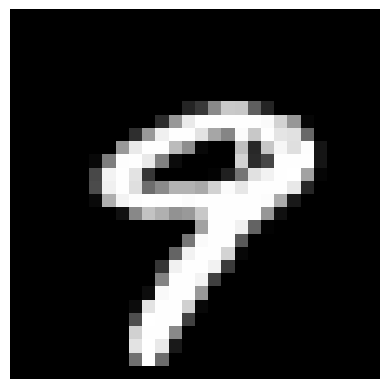

In [18]:
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

for i in range(10):
    img, label = dataset[i]

    plt.imshow(img, cmap="gray")
    plt.axis("off")

    img.save(f"{label}.png")

    print(f"Saved {label}.png")